**Car price prediction**

In [1]:
# importing necessary libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

**loading data set**

In [2]:
data = pd.read_csv("/content/Car_data_jtrjuw.csv")

In [3]:
data.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [4]:
data.tail()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
296,city,2016,9.50,11.6,33988,Diesel,Dealer,Manual,0
297,brio,2015,4.00,5.9,60000,Petrol,Dealer,Manual,0
298,city,2009,3.35,11.0,87934,Petrol,Dealer,Manual,0
299,city,2017,11.50,12.5,9000,Diesel,Dealer,Manual,0
300,brio,2016,5.30,5.9,5464,Petrol,Dealer,Manual,0


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Seller_Type    301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB


In [7]:
data.shape

(301, 9)

In [8]:
data.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [9]:
print(data.isnull().sum())

Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64


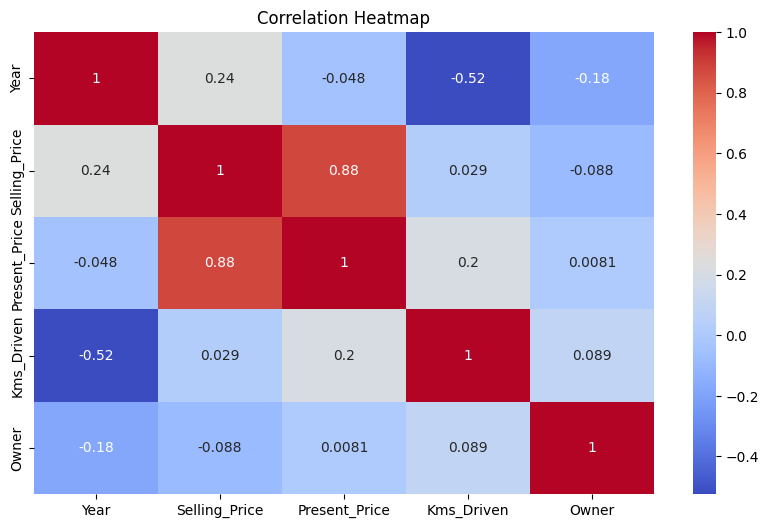

In [10]:
#corelation heatmab

plt.figure(figsize=(10,6))
sns.heatmap(data.corr(numeric_only=True),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

Distribution of car price

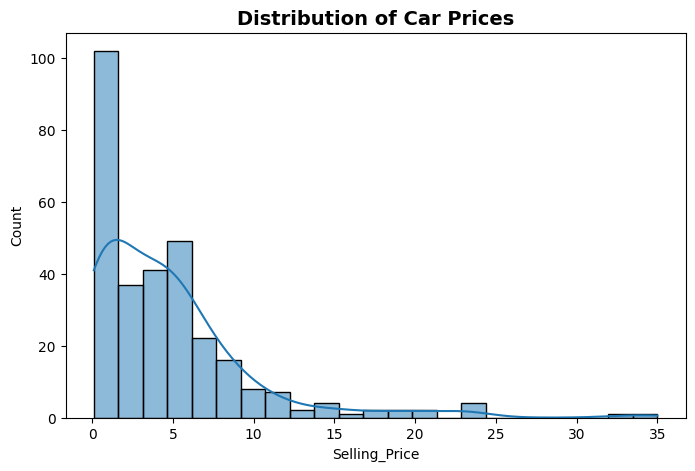

In [12]:
plt.figure(figsize=(8,5))

sns.histplot(data['Selling_Price'],
             kde=True)

plt.title("Distribution of Car Prices",
          fontsize=14,
          fontweight='bold')

plt.show()

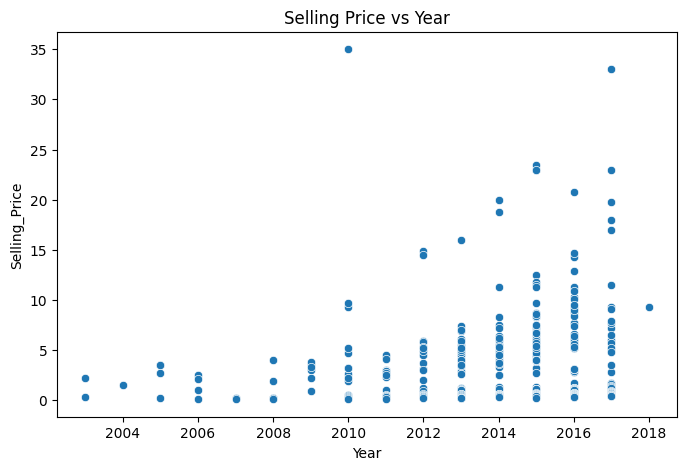

In [14]:
plt.figure(figsize=(8,5))

sns.scatterplot(x='Year',
                y='Selling_Price',
                data=data)

plt.title("Selling Price vs Year")
plt.show()

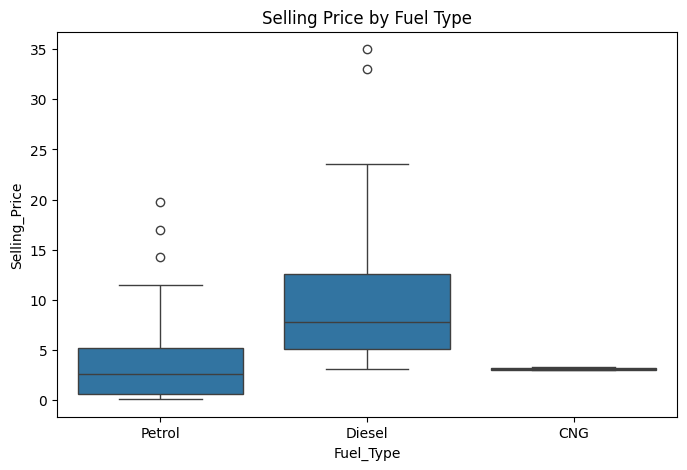

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Fuel_Type',
            y='Selling_Price',
            data=data)

plt.title("Selling Price by Fuel Type")
plt.show()

Data preprocessing

In [18]:
# seperating features and target

X = data.drop("Selling_Price", axis=1)
y = data["Selling_Price"]

In [19]:
# idetifying nemerical and categorical colums

num_cols = X.select_dtypes(include=['int64','float64']).columns

cat_cols = X.select_dtypes(include=['object']).columns

Preprocessing Pipeline
Numerical Features
Fill missing values with median
Categorical Features
Fill missing values with most frequent value
One-Hot Encoding **bold text**

In [20]:
from sklearn.preprocessing import OneHotEncoder

numeric_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore'))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ]
)

**Model Building**

In [21]:
# train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

**linear regression model**

In [22]:
model = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('regressor', LinearRegression())
    ]
)

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  Index(['Year', 'Present_Price', 'Kms_Driven', 'Owner'], dtype='object')),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  Index(['Car_Name', 'Fuel_Type', 'Seller_Type', 'Transmission'], dtype='object'))])),
                ('regressor', LinearRegression())])

**Model Evaluation**

In [23]:
# making predictions

y_pred = model.predict(X_test)

In [24]:
# MAE

mae = mean_absolute_error(y_test, y_pred)
print("Mean Absolute Error:", mae)


Mean Absolute Error: 1.1021419132144532


In [25]:
# RMSE

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("Root Mean Squared Error:", rmse)

Root Mean Squared Error: 1.5123400413676051


In [26]:
r2_score = r2_score(y_test, y_pred)
print("R-squared Score:", r2_score)

R-squared Score: 0.9007113364668833


**predicting prices for 5 samples cars**

In [27]:
sample_cars = X_test.head(5)

predicted_prices = model.predict(sample_cars)

results = sample_cars.copy()

results["Predicted Price"] = predicted_prices

print(results)

               Car_Name  Year  Present_Price  Kms_Driven Fuel_Type  \
177    Honda Activa 125  2016           0.57       24000    Petrol   
289                city  2016          13.60       10980    Petrol   
228               verna  2012           9.40       60000    Diesel   
198  Bajaj Discover 125  2011           0.57       35000    Petrol   
60        corolla altis  2013          18.61       40001    Petrol   

    Seller_Type Transmission  Owner  Predicted Price  
177  Individual    Automatic      0         1.494463  
289      Dealer       Manual      0         9.593119  
228      Dealer       Manual      0         5.505179  
198  Individual       Manual      1        -0.409634  
60       Dealer       Manual      0         8.564933  


**Feature importance Analysis**

In [28]:
# linear regression

feature_names = model.named_steps['preprocessor'].get_feature_names_out()

coefficients = model.named_steps['regressor'].coef_

importance = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
})

importance = importance.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

print(importance.head(10))

                                    Feature  Coefficient
84               cat__Car_Name_land cruiser   -19.913799
64                      cat__Car_Name_camry    -7.675088
4                         cat__Car_Name_800     5.967171
31        cat__Car_Name_Hero Super Splendor     5.484534
1                        num__Present_Price     5.430378
34             cat__Car_Name_Honda CB Shine     4.230670
26                  cat__Car_Name_Hero Hunk     3.925768
20           cat__Car_Name_Hero  CBZ Xtreme     3.595783
49          cat__Car_Name_Suzuki Access 125     3.334921
46  cat__Car_Name_Royal Enfield Classic 500     3.103391


**Factors** That Most Influence Car Price

After analyzing the coefficients and visualizations, the most influential factors were:

Car age (Year)
Mileage/Kilometers driven
Engine size
Brand
Fuel type
Transmission type
Observations
Newer cars generally have higher prices.
Cars with lower mileage sell for more.
Premium brands command significantly higher prices.
Automatic transmission vehicles often have higher resale value.
Surprising Findings
Some older luxury vehicles still maintain high prices.
Certain fuel types showed only a small impact on price.
Brand reputation influenced price more than engine size in many cases.
Conclusion

A Linear Regression model was built to predict used car prices. The model was evaluated using:

MAE
RMSE
R² Score

The results show how vehicle age, mileage, brand, and engine specifications affect the selling price, helping the marketplace estimate fair market values for used cars.